# Project Setup

Enable GPU

In [ ]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("WARNING: GPU is not available.")

PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


Install libraries

In [ ]:
!pip install -q datasets transformers accelerate sentencepiece gensim scikit-learn pandas numpy matplotlib seaborn nltk wordcloud

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.8/27.8 MB 25.4 MB/s eta 0:00:00


In [ ]:
!pip install -q gensim tensorflow

In [ ]:
!wget -q --show-progress \
    https://nlp.stanford.edu/data/glove.twitter.27B.zip
!unzip -q glove.twitter.27B.zip

glove.twitter.27B.z 100%[===================>]   1.42G  4.99MB/s    in 4m 44s  


In [ ]:
!pip install -q transformers accelerate evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.7 MB/s eta 0:00:00


In [ ]:
import os
import re
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter

warnings.filterwarnings("ignore")

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

print("Environment setup completed.")
print("Random seed:", SEED)

Environment setup completed.
Random seed: 42


In [ ]:
import tensorflow as tf
import gensim

print("TensorFlow:", tf.__version__)
print("Gensim:", gensim.__version__)
print("GPU available:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.20.0
Gensim: 4.4.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
import os

print(
    os.path.exists(
        "glove.twitter.27B.100d.txt"
    )
)

False


In [ ]:
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    EarlyStoppingCallback
)

print(
    "Transformers libraries loaded successfully."
)

Transformers libraries loaded successfully.


# Dataset Collection

Load Dataset and construct target class

In [ ]:
!pip install -q datasets pandas pyarrow

from datasets import load_dataset
import pandas as pd

print("Streaming 50,000 rows instantly from Hugging Face...")

dataset = load_dataset("librarian-bots/arxiv-metadata-snapshot", split="train", streaming=True)

dataset = dataset.shuffle(
    seed=SEED,
    buffer_size=100000
)


subset = list(dataset.take(50000))
df = pd.DataFrame(subset)
print(f"Extraction complete! Initial Dataframe Shape: {df.shape}")


df['target_classname'] = df['categories'].apply(lambda x: x.split()[0] if len(x.split()) > 0 else 'unknown')

df['target_classname'] = df['target_classname'].apply(lambda x: x.split('.')[0])


physics_archives = ['astro-ph', 'cond-mat', 'gr-qc', 'hep-ex', 'hep-lat',
                    'hep-ph', 'hep-th', 'math-ph', 'nlin', 'nucl-ex', 'nucl-th', 'quant-ph']
df['target_classname'] = df['target_classname'].apply(lambda x: 'physics' if x in physics_archives else x)


valid_classes = ['cs', 'math', 'physics', 'stat', 'q-bio', 'q-fin', 'eess', 'econ']
df = df[df['target_classname'].isin(valid_classes)]


df.to_csv('arxiv_sampled_50k.csv', index=False)
print("\nSaved file to disk as 'arxiv_sampled_50k.csv'. Data is locked in!")


print("\nYour final multi-class distribution counts:")
print(df['target_classname'].value_counts())

Streaming 50,000 rows instantly from Hugging Face...


README.md:   0%|          | 0.00/2.32k [00:00<?, ?B/s]

Extraction complete! Initial Dataframe Shape: (50000, 14)

Saved file to disk as 'arxiv_sampled_50k.csv'. Data is locked in!

Your final multi-class distribution counts:
target_classname
physics    21774
cs         13291
math       10462
eess        2031
stat        1341
q-bio        682
q-fin        269
econ         136
Name: count, dtype: int64


# Dataset Validation

Create Actual Text

In [ ]:
df["title"] = df["title"].fillna("")
df["abstract"] = df["abstract"].fillna("")

df["text"] = (
    df["title"].astype(str)
    + " "
    + df["abstract"].astype(str)
)

df["text"] = df["text"].str.strip()

df = df[
    df["text"].str.len() > 20
].copy()

before_duplicates = len(df)

df = df.drop_duplicates(
    subset=["text"]
).reset_index(drop=True)

after_duplicates = len(df)

print(
    "Duplicates removed:",
    before_duplicates - after_duplicates
)

Duplicates removed: 0


In [ ]:
print("=" * 60)
print("FINAL DATASET SUMMARY")
print("=" * 60)

print("\nShape:")
print(df.shape)

print("\nClass distribution:")
print(
    df["target_classname"].value_counts()
)

print("\nMissing values:")
print(
    df[
        ["title", "abstract", "text", "target_classname"]
    ].isnull().sum()
)

print("\nDuplicate texts:")
print(
    df["text"].duplicated().sum()
)

class_counts = (
    df["target_classname"]
    .value_counts()
    .sort_values(ascending=False)
)

print("\nClass percentages:")
print(
    (class_counts / len(df) * 100).round(2)
)

FINAL DATASET SUMMARY

Shape:
(49986, 16)

Class distribution:
target_classname
physics    21774
cs         13291
math       10462
eess        2031
stat        1341
q-bio        682
q-fin        269
econ         136
Name: count, dtype: int64

Missing values:
title               0
abstract            0
text                0
target_classname    0
dtype: int64

Duplicate texts:
0

Class percentages:
target_classname
physics    43.56
cs         26.59
math       20.93
eess        4.06
stat        2.68
q-bio       1.36
q-fin       0.54
econ        0.27
Name: count, dtype: float64


# Exploratory Data Analysis

Dataset overview

In [ ]:
print("=" * 70)
print("DATASET OVERVIEW")
print("=" * 70)

print(f"\nDataset Shape: {df.shape}")

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
display(df.dtypes)

print("\nFirst 5 Rows:")
display(df.head())

DATASET OVERVIEW

Dataset Shape: (49986, 16)

Column Names:
['id', 'submitter', 'authors', 'title', 'comments', 'journal-ref', 'doi', 'report-no', 'categories', 'license', 'abstract', 'versions', 'update_date', 'authors_parsed', 'target_classname', 'text']

Data Types:


,0
id,object
submitter,object
authors,object
title,object
comments,object
journal-ref,object
doi,object
report-no,object
categories,object
license,object



First 5 Rows:


,id,submitter,authors,title,comments,journal-ref,doi,report-no,categories,license,abstract,versions,update_date,authors_parsed,target_classname,text
0,2004.12183,Christian Wressnegger,Tim Witschel and Christian Wressnegger,"Aim Low, Shoot High: Evading Aimbot Detectors ...",6 pages,European Workshop on Systems Security (EuroSec...,10.1145/3380786.3391397,None,cs.CR,http://arxiv.org/licenses/nonexclusive-distrib...,Current schemes to detect cheating in online...,"[{'version': 'v1', 'created': 'Sat, 25 Apr 202...",2020-04-28,"[[Witschel, Tim, ], [Wressnegger, Christian, ]]",cs,"Aim Low, Shoot High: Evading Aimbot Detectors ..."
1,1910.11632,Michael J. Klaiber,"Michael J. Klaiber, Sebastian Vogel, Axel Acos...",An End-to-End HW/SW Co-Design Methodology to D...,None,"Embedded Systems Week 2019, INTelligent Embedd...",10.1145/3372394.3372396,None,cs.LG cs.DC stat.ML,http://arxiv.org/licenses/nonexclusive-distrib...,End-to-end performance estimation and measur...,"[{'version': 'v1', 'created': 'Fri, 25 Oct 201...",2019-11-19,"[[Klaiber, Michael J., ], [Vogel, Sebastian, ]...",cs,An End-to-End HW/SW Co-Design Methodology to D...
2,1908.09907,Pavol Neilinger,"P. Neilinger, J. Gregu\v{s}, D. Manca, B. Gran...",Observation of quantum corrections to conducti...,"8 pages, 6 figures","Phys. Rev. B 100, 241106 (2019)",10.1103/PhysRevB.100.241106,None,cond-mat.mes-hall cond-mat.dis-nn cond-mat.str...,http://arxiv.org/licenses/nonexclusive-distrib...,It is well known that conductivity of disord...,"[{'version': 'v1', 'created': 'Mon, 26 Aug 201...",2019-12-18,"[[Neilinger, P., ], [Greguš, J., ], [Manca, D....",physics,Observation of quantum corrections to conducti...
3,2002.02926,Iwan Praton,Iwan Praton,Tilings with the Minimal Tile Property,None,None,None,None,math.MG,http://arxiv.org/licenses/nonexclusive-distrib...,A square tiling of the unit square is said t...,"[{'version': 'v1', 'created': 'Fri, 7 Feb 2020...",2020-02-10,"[[Praton, Iwan, ]]",math,Tilings with the Minimal Tile Property A squ...
4,2002.03409,Wojciech Chach\'olski,Wojciech Chacholski and Alvin Jin and Martina ...,Homotopical decompositions of simplicial and V...,None,None,None,None,math.AT,http://arxiv.org/licenses/nonexclusive-distrib...,Motivated by applications in Topological Dat...,"[{'version': 'v1', 'created': 'Sun, 9 Feb 2020...",2020-02-11,"[[Chacholski, Wojciech, ], [Jin, Alvin, ], [Sc...",math,Homotopical decompositions of simplicial and V...


Missing value analysis

,Missing Values,Percentage
report-no,48100,96.226944
journal-ref,34725,69.469451
doi,27992,55.999680
comments,15524,31.056696
license,800,1.600448
submitter,39,0.078022
id,0,0.000000
title,0,0.000000
authors,0,0.000000
categories,0,0.000000



Total Missing Values: 127180


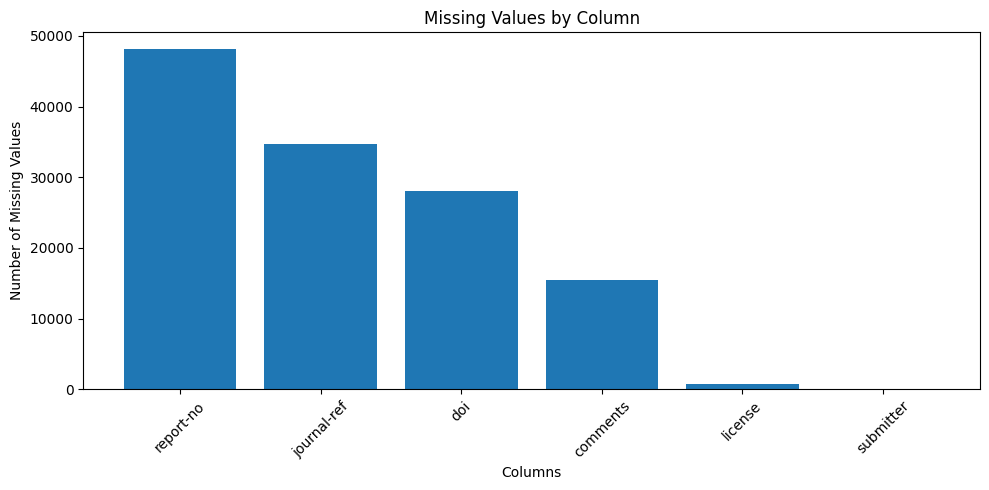

In [ ]:
missing_values = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": (
        df.isnull().sum() / len(df) * 100
    )
})

missing_values = missing_values.sort_values(
    by="Missing Values",
    ascending=False
)

display(missing_values)

print("\nTotal Missing Values:", df.isnull().sum().sum())
missing_plot = missing_values[
    missing_values["Missing Values"] > 0
]

if len(missing_plot) > 0:

    plt.figure(figsize=(10, 5))

    plt.bar(
        missing_plot.index,
        missing_plot["Missing Values"]
    )

    plt.title("Missing Values by Column")
    plt.xlabel("Columns")
    plt.ylabel("Number of Missing Values")

    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

else:
    print("No missing values found in the dataset.")

Duplicate Analysis

In [ ]:
if "abstract" in df.columns:

    abstract_duplicates = df.duplicated(
        subset=["abstract"]
    ).sum()

    print(
        "Duplicate Abstracts:",
        abstract_duplicates
    )

if "title" in df.columns:

    title_duplicates = df.duplicated(
        subset=["title"]
    ).sum()

    print(
        "Duplicate Titles:",
        title_duplicates
    )

Duplicate Abstracts: 1
Duplicate Titles: 6


Class Distribution table

In [ ]:
class_distribution = pd.DataFrame({
    "Count": df["target_classname"].value_counts(),
    "Percentage": (
        df["target_classname"]
        .value_counts(normalize=True)
        * 100
    )
})

class_distribution = class_distribution.sort_values(
    by="Count",
    ascending=False
)

class_distribution["Percentage"] = (
    class_distribution["Percentage"].round(2)
)

display(class_distribution)

,Count,Percentage
target_classname,,
physics,21774,43.56
cs,13291,26.59
math,10462,20.93
eess,2031,4.06
stat,1341,2.68
q-bio,682,1.36
q-fin,269,0.54
econ,136,0.27


Class imbalance ratio

CLASS IMBALANCE ANALYSIS
Largest Class Size: 21774
Smallest Class Size: 136
Imbalance Ratio: 160.10:1


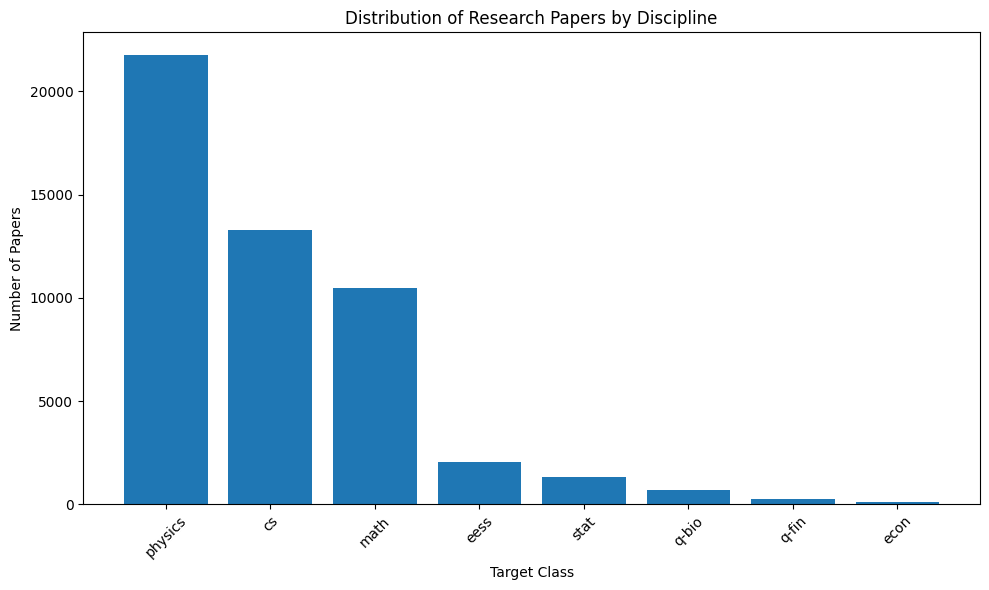

In [ ]:
class_counts = df[
    "target_classname"
].value_counts()

largest_class = class_counts.max()
smallest_class = class_counts.min()

imbalance_ratio = (
    largest_class / smallest_class
)

print("=" * 70)
print("CLASS IMBALANCE ANALYSIS")
print("=" * 70)

print(f"Largest Class Size: {largest_class}")
print(f"Smallest Class Size: {smallest_class}")

print(
    f"Imbalance Ratio: "
    f"{imbalance_ratio:.2f}:1"
)
class_counts = (
    df["target_classname"]
    .value_counts()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

plt.bar(
    class_counts.index,
    class_counts.values
)

plt.title("Distribution of Research Papers by Discipline")
plt.xlabel("Target Class")
plt.ylabel("Number of Papers")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Text length statistics

In [ ]:
df["title_length"] = (
    df["title"]
    .fillna("")
    .astype(str)
    .str.len()
)

df["abstract_length"] = (
    df["abstract"]
    .fillna("")
    .astype(str)
    .str.len()
)

print("=" * 70)
print("TEXT LENGTH STATISTICS")
print("=" * 70)

print("\nTITLE LENGTH:")
display(
    df["title_length"].describe()
)

print("\nABSTRACT LENGTH:")
display(
    df["abstract_length"].describe()
)

TEXT LENGTH STATISTICS

TITLE LENGTH:


,title_length
count,49986.000000
mean,75.758272
std,27.442436
min,6.000000
25%,56.000000
50%,72.000000
75%,92.000000
max,244.000000



ABSTRACT LENGTH:


,abstract_length
count,49986.000000
mean,1007.471932
std,413.120536
min,19.000000
25%,701.000000
50%,990.000000
75%,1295.000000
max,3506.000000


Word count analysis

In [ ]:
df["title_word_count"] = (
    df["title"]
    .fillna("")
    .astype(str)
    .apply(lambda x: len(x.split()))
)

df["abstract_word_count"] = (
    df["abstract"]
    .fillna("")
    .astype(str)
    .apply(lambda x: len(x.split()))
)

print("=" * 70)
print("WORD COUNT STATISTICS")
print("=" * 70)

print("\nTITLE WORD COUNT:")
display(
    df["title_word_count"].describe()
)

print("\nABSTRACT WORD COUNT:")
display(
    df["abstract_word_count"].describe()
)

WORD COUNT STATISTICS

TITLE WORD COUNT:


,title_word_count
count,49986.000000
mean,9.831293
std,3.690248
min,1.000000
25%,7.000000
50%,9.000000
75%,12.000000
max,36.000000



ABSTRACT WORD COUNT:


,abstract_word_count
count,49986.000000
mean,148.005822
std,61.082814
min,3.000000
25%,103.000000
50%,145.000000
75%,190.000000
max,528.000000


Abstract length distribution and abstract word count by discipline

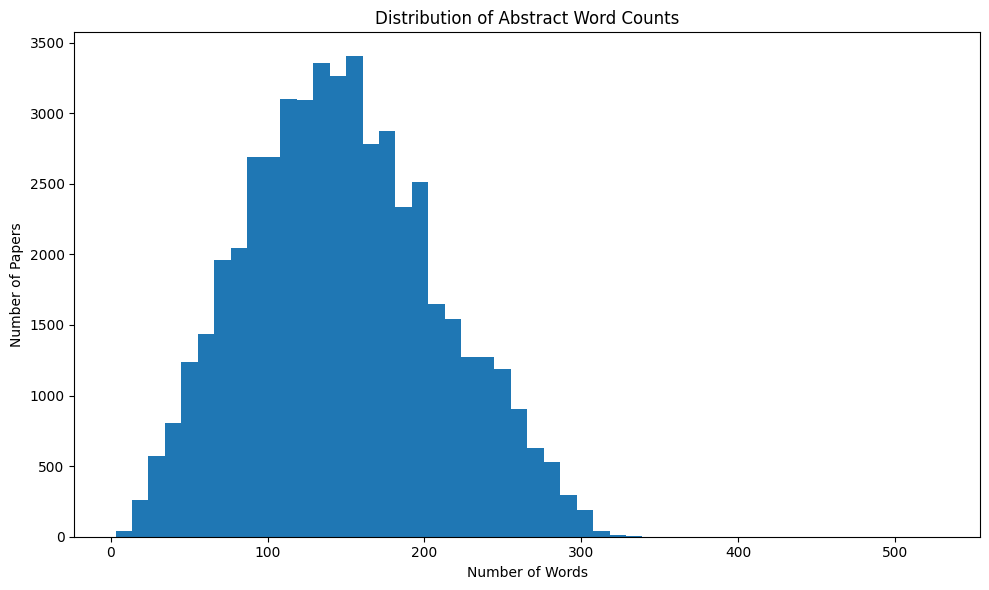

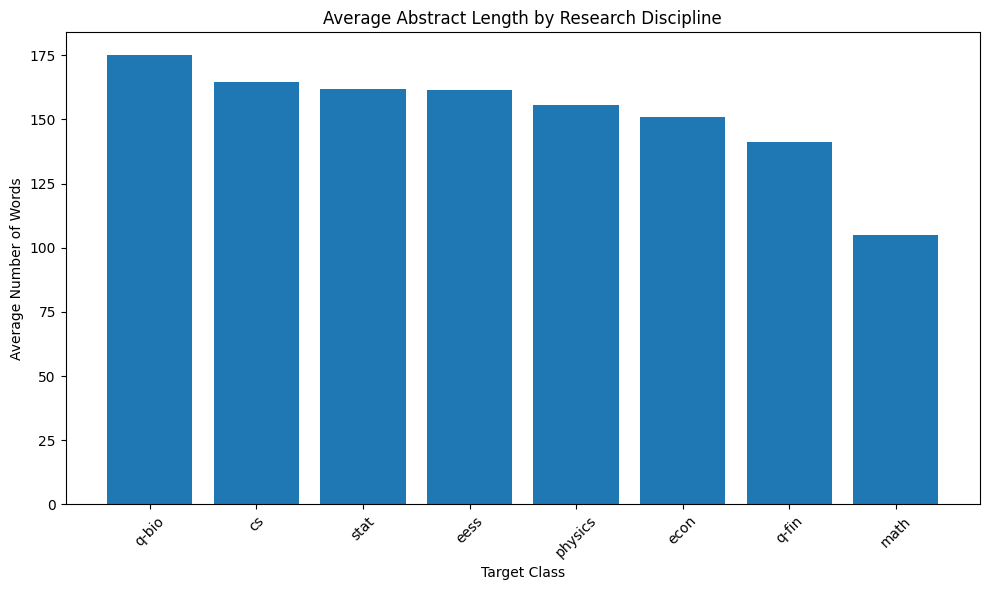

,Average Word Count
target_classname,
q-bio,175.209677
cs,164.792491
stat,161.986577
eess,161.604136
physics,155.495407
econ,150.941176
q-fin,141.394052
math,105.018830


,Median Word Count
target_classname,
q-bio,174.0
cs,162.0
stat,161.0
eess,159.0
physics,149.0
econ,143.0
q-fin,136.0
math,95.0


,Number_of_Papers,Avg_Title_Words,Avg_Abstract_Words,Median_Abstract_Words,Min_Abstract_Words,Max_Abstract_Words
target_classname,,,,,,
physics,21774,10.56,155.50,149.0,3,528
cs,13291,9.12,164.79,162.0,5,488
math,10462,9.04,105.02,95.0,3,335
eess,2031,10.44,161.60,159.0,15,306
stat,1341,9.53,161.99,161.0,24,302
q-bio,682,11.47,175.21,174.0,25,335
q-fin,269,9.74,141.39,136.0,13,304
econ,136,10.12,150.94,143.0,34,288


In [ ]:
plt.figure(figsize=(10, 6))

plt.hist(
    df["abstract_word_count"],
    bins=50
)

plt.title("Distribution of Abstract Word Counts")
plt.xlabel("Number of Words")
plt.ylabel("Number of Papers")

plt.tight_layout()
plt.show()
average_length_by_class = (
    df.groupby("target_classname")[
        "abstract_word_count"
    ]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

plt.bar(
    average_length_by_class.index,
    average_length_by_class.values
)

plt.title("Average Abstract Length by Research Discipline")
plt.xlabel("Target Class")
plt.ylabel("Average Number of Words")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

display(
    average_length_by_class.to_frame(
        "Average Word Count"
    )
)
median_length_by_class = (
    df.groupby("target_classname")[
        "abstract_word_count"
    ]
    .median()
    .sort_values(ascending=False)
)

display(
    median_length_by_class.to_frame(
        "Median Word Count"
    )
)
text_stats_by_class = (
    df.groupby("target_classname")
    .agg(
        Number_of_Papers=(
            "target_classname",
            "count"
        ),
        Avg_Title_Words=(
            "title_word_count",
            "mean"
        ),
        Avg_Abstract_Words=(
            "abstract_word_count",
            "mean"
        ),
        Median_Abstract_Words=(
            "abstract_word_count",
            "median"
        ),
        Min_Abstract_Words=(
            "abstract_word_count",
            "min"
        ),
        Max_Abstract_Words=(
            "abstract_word_count",
            "max"
        )
    )
    .round(2)
    .sort_values(
        "Number_of_Papers",
        ascending=False
    )
)

display(text_stats_by_class)

Category analysis

,num_categories
count,49986.000000
mean,1.831293
std,0.977616
min,1.000000
25%,1.000000
50%,2.000000
75%,2.000000
max,8.000000



Average Categories Per Paper: 1.83


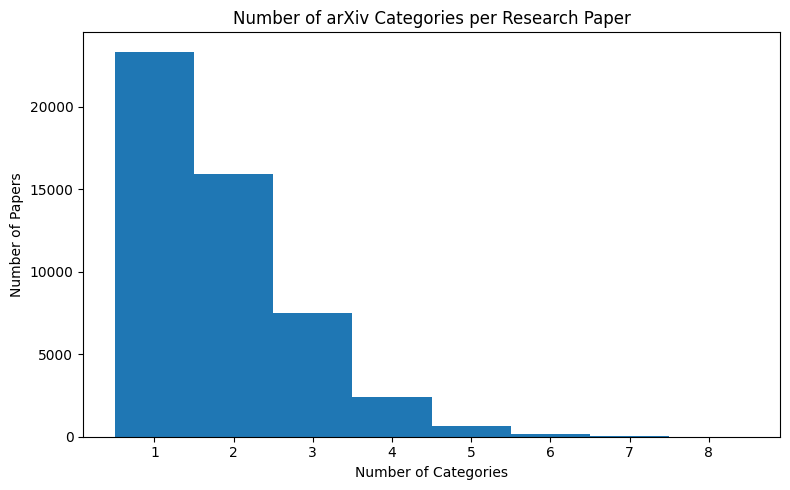

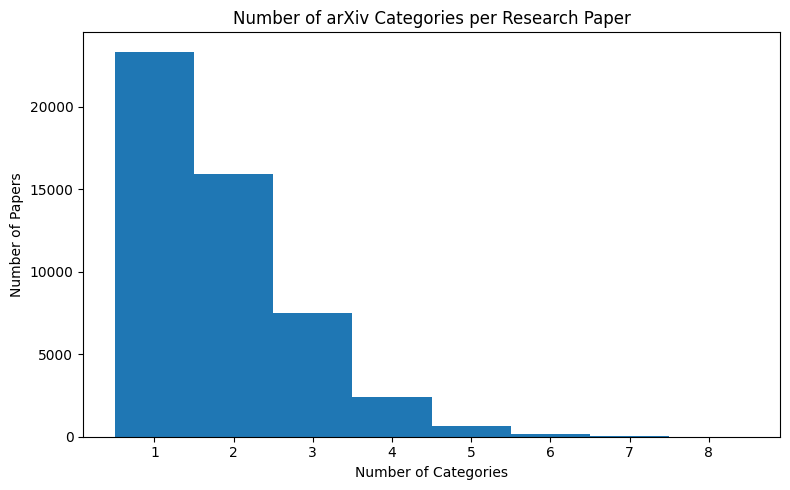

MULTI-CATEGORY ANALYSIS
Single Category Papers: 23356
Multi-Category Papers: 26630
Percentage Multi-Category: 53.27%


In [ ]:
df["num_categories"] = (
    df["categories"]
    .fillna("")
    .astype(str)
    .apply(lambda x: len(x.split()))
)

display(
    df["num_categories"].describe()
)

print(
    "\nAverage Categories Per Paper:",
    round(df["num_categories"].mean(), 2)
)

plt.figure(figsize=(8, 5))

plt.hist(
    df["num_categories"],
    bins=range(
        1,
        int(df["num_categories"].max()) + 2
    ),
    align="left"
)

plt.title("Number of arXiv Categories per Research Paper")
plt.xlabel("Number of Categories")
plt.ylabel("Number of Papers")

plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))

plt.hist(
    df["num_categories"],
    bins=range(
        1,
        int(df["num_categories"].max()) + 2
    ),
    align="left"
)

plt.title("Number of arXiv Categories per Research Paper")
plt.xlabel("Number of Categories")
plt.ylabel("Number of Papers")

plt.tight_layout()
plt.show()

multi_category_count = (
    df["num_categories"] > 1
).sum()

single_category_count = (
    df["num_categories"] == 1
).sum()

print("=" * 70)
print("MULTI-CATEGORY ANALYSIS")
print("=" * 70)

print(
    f"Single Category Papers: "
    f"{single_category_count}"
)

print(
    f"Multi-Category Papers: "
    f"{multi_category_count}"
)

print(
    f"Percentage Multi-Category: "
    f"{(multi_category_count / len(df)) * 100:.2f}%"
)

Most common original arXiv categories

,Category,Count
0,cs.LG,5848
1,stat.ML,3676
2,cs.CV,3635
3,quant-ph,2601
4,hep-th,2300
5,hep-ph,2228
6,cond-mat.mtrl-sci,1810
7,cond-mat.mes-hall,1745
8,cs.CL,1695
9,gr-qc,1662


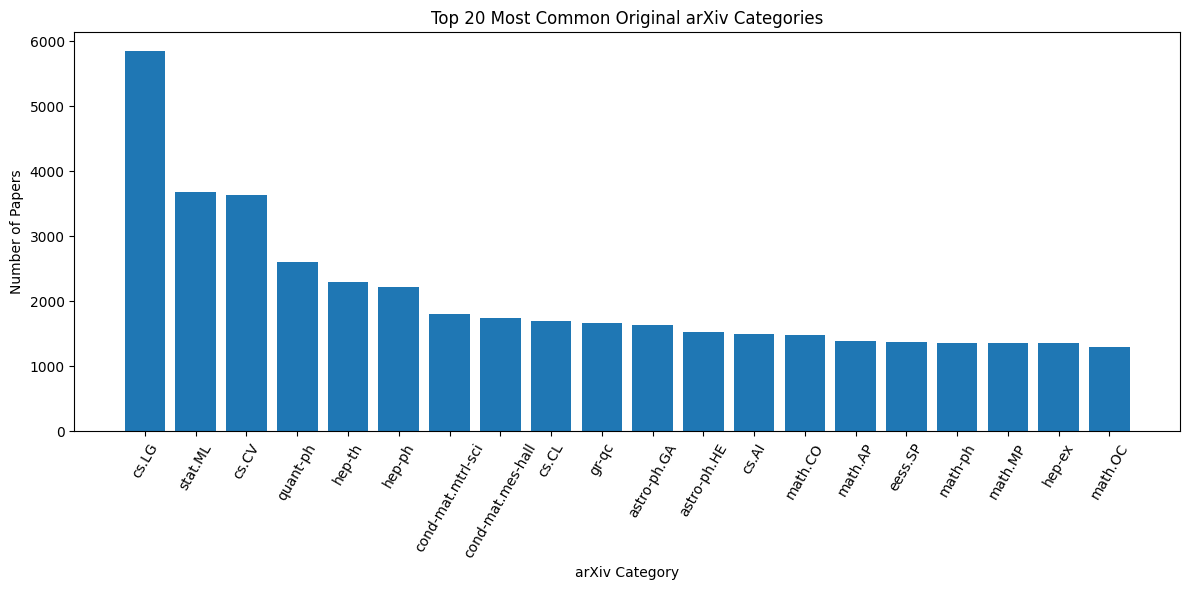

In [ ]:
from collections import Counter

all_categories = []

for category_string in df["categories"].fillna(""):

    all_categories.extend(
        category_string.split()
    )

category_counts = Counter(all_categories)

top_categories = pd.DataFrame(
    category_counts.most_common(20),
    columns=[
        "Category",
        "Count"
    ]
)

display(top_categories)

plt.figure(figsize=(12, 6))

plt.bar(
    top_categories["Category"],
    top_categories["Count"]
)

plt.title("Top 20 Most Common Original arXiv Categories")
plt.xlabel("arXiv Category")
plt.ylabel("Number of Papers")

plt.xticks(rotation=60)

plt.tight_layout()
plt.show()

Title vs abstract length relationship

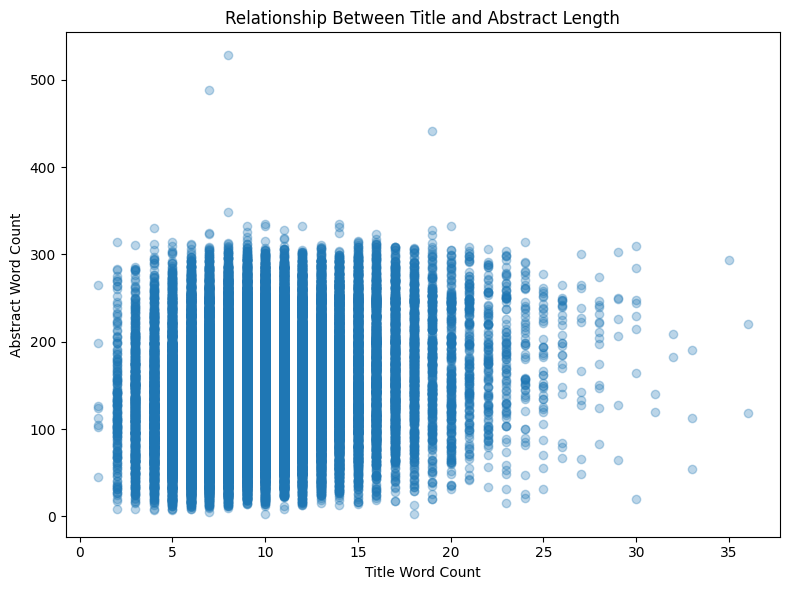


Correlation Matrix:


,title_word_count,abstract_word_count
title_word_count,1.000000,0.199918
abstract_word_count,0.199918,1.000000


In [ ]:
plt.figure(figsize=(8, 6))

plt.scatter(
    df["title_word_count"],
    df["abstract_word_count"],
    alpha=0.3
)

plt.title("Relationship Between Title and Abstract Length")
plt.xlabel("Title Word Count")
plt.ylabel("Abstract Word Count")

plt.tight_layout()
plt.show()

correlation = df[
    ["title_word_count", "abstract_word_count"]
].corr()

print("\nCorrelation Matrix:")
display(correlation)

Random examples from each class

In [ ]:
for target_class in sorted(
    df["target_classname"].unique()
):

    print("\n" + "=" * 80)
    print(f"CLASS: {target_class}")
    print("=" * 80)

    sample = (
        df[
            df["target_classname"] == target_class
        ]
        .sample(
            1,
            random_state=42
        )
    )

    print(
        "TITLE:",
        sample["title"].iloc[0]
    )

    print(
        "\nABSTRACT:",
        sample["abstract"].iloc[0][:500],
        "..."
    )


CLASS: cs
TITLE: Infrared and Visible Image Fusion with ResNet and zero-phase component
  analysis

ABSTRACT:   Feature extraction and processing tasks play a key role in Image Fusion, and
the fusion performance is directly affected by the different features and
processing methods undertaken. By contrast, most of deep learning-based methods
use deep features directly without feature extraction or processing. This leads
to the fusion performance degradation in some cases. To solve these drawbacks,
we propose a deep features and zero-phase component analysis (ZCA) based novel
fusion framework is this pape ...

CLASS: econ
TITLE: Estimation and simulation of the transaction arrival process in intraday
  electricity markets

ABSTRACT:   We examine the novel problem of the estimation of transaction arrival
processes in the intraday electricity markets. We model the inter-arrivals
using multiple time-varying parametric densities based on the generalized F
distribution estimated by maximum l

EDA Plot

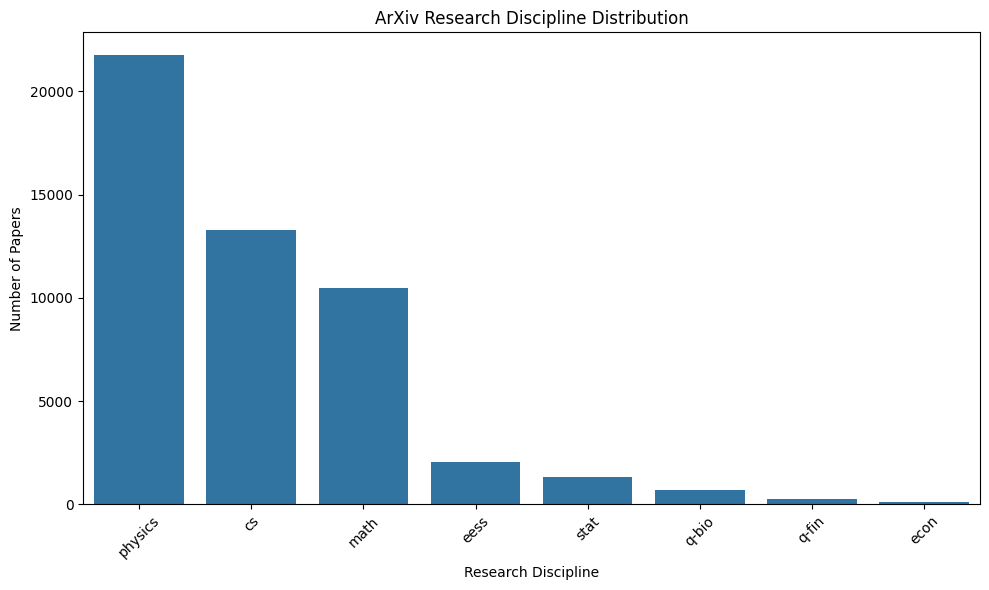

In [ ]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=class_counts.index,
    y=class_counts.values
)

plt.title("ArXiv Research Discipline Distribution")
plt.xlabel("Research Discipline")
plt.ylabel("Number of Papers")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

count    49986.000000
mean       157.837114
std         61.926211
min         11.000000
25%        112.000000
50%        155.000000
75%        200.000000
max        536.000000
Name: word_count, dtype: float64


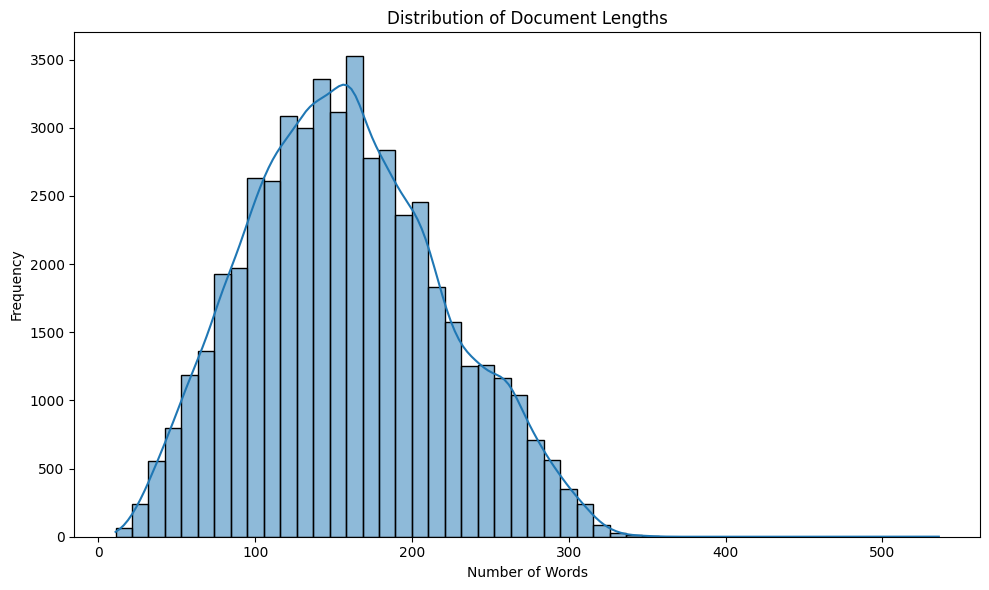

In [ ]:
df["word_count"] = df["text"].apply(
    lambda x: len(x.split())
)

print(df["word_count"].describe())

plt.figure(figsize=(10, 6))

sns.histplot(
    df["word_count"],
    bins=50,
    kde=True
)

plt.title("Distribution of Document Lengths")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

# Data Preprocessing

## Justification of Preprocessing

Preprocessing was performed to improve the quality and consistency of the textual data before training the machine learning and deep learning models. Since the dataset consists of research paper metadata and abstracts, the preprocessing strategy was designed to preserve meaningful academic and technical information while removing unnecessary noise.

### Handling Missing Values

Missing values in important textual fields such as the title and abstract were checked and handled before model training. This was necessary because machine learning and natural language processing models require valid textual input and cannot effectively process missing or null values.

### Removing Duplicate Records

Duplicate records were checked and removed to avoid repeated research papers appearing in both the training and evaluation process. Duplicate samples can lead to data leakage and artificially increase model performance.

### Text Cleaning

Textual content was cleaned to remove unnecessary whitespace and formatting inconsistencies. This improves consistency across research paper abstracts and titles while preserving meaningful technical vocabulary.

Heavy preprocessing such as aggressive removal of punctuation and technical terms was avoided because research paper abstracts contain domain-specific terminology, mathematical expressions, abbreviations, and technical phrases that may provide useful information for classification.

### Combining Textual Features

The title and abstract were combined to create a richer textual representation of each research paper. The title provides a concise summary of the research topic, while the abstract contains more detailed contextual information. Combining these fields allows the models to use both high-level topic information and detailed research content.

### Label Processing

The original arXiv categories were mapped into eight major target disciplines:

- Computer Science
- Mathematics
- Physics
- Statistics
- Quantitative Biology
- Quantitative Finance
- Electrical Engineering and Systems Science
- Economics

This transformation converted the task into a multi-class classification problem. Label encoding was then used to convert the categorical target classes into numerical values required by machine learning and neural network models.

### Train, Validation, and Test Splitting

The dataset was divided into training, validation, and test sets using a fixed random seed. Stratified splitting was used to preserve the class distribution across the different subsets.

The training set was used for learning model parameters, the validation set was used for hyperparameter selection and model configuration comparison, and the test set was reserved for final evaluation. This separation helps reduce the risk of overfitting and ensures a fair comparison between models.

### TF-IDF Representation

TF-IDF was used for the classical machine learning models because it represents documents based on the importance of words within the dataset. Common words receive lower importance, while words that are more distinctive to particular documents or disciplines receive higher weights.

This representation is particularly suitable for models such as Logistic Regression, Naive Bayes, and Random Forest.

### Sequence Preparation for RNN Models

For the recurrent neural network models, the text was tokenized and converted into numerical sequences. The sequences were padded or truncated to a fixed maximum length.

Padding was necessary because neural network models require input sequences of consistent length within a batch. The sequence representation allows RNN-based models to learn relationships between words and capture sequential patterns in the text.

### Transformer Tokenization

BERT used its own pretrained tokenizer rather than the manually processed TF-IDF or RNN sequences. The BERT tokenizer converts text into subword tokens and includes special tokens required by the transformer architecture.

Minimal preprocessing was applied before BERT tokenization because aggressive text cleaning could remove information that the pretrained language model uses to understand contextual relationships.

### Overall Justification

Different preprocessing and representation strategies were used because the models have different input requirements. Classical machine learning models benefit from sparse statistical representations such as TF-IDF, recurrent neural networks require ordered numerical sequences, and transformer models use contextual token representations.

Using model-specific preprocessing allowed each model to operate with the type of textual representation most suitable for its architecture.

Encide target labels

In [ ]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

df["label"] = label_encoder.fit_transform(
    df["target_classname"]
)

class_names = label_encoder.classes_

print("Class mapping:")
for index, class_name in enumerate(class_names):
    print(f"{index} -> {class_name}")

print("\nNumber of classes:", len(class_names))

Class mapping:
0 -> cs
1 -> econ
2 -> eess
3 -> math
4 -> physics
5 -> q-bio
6 -> q-fin
7 -> stat

Number of classes: 8


# Train/Validation/Test Split

In [ ]:
X = df["text"].values
y = df["label"].values

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nFirst document:")
print(X[0][:500])

print("\nFirst label:")
print(y[0])

X shape: (49986,)
y shape: (49986,)

First document:
Aim Low, Shoot High: Evading Aimbot Detectors by Mimicking User Behavior   Current schemes to detect cheating in online games often build on the
assumption that the applied cheat takes actions that are drastically different
from normal behavior. For instance, an Aimbot for a first-person shooter is
used by an amateur player to increase his/her capabilities many times over.
Attempts to evade detection would require to reduce the intended effect such
that the advantage is presumably lowered into i

First label:
0


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=SEED
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=SEED
)

print("Training samples:", len(X_train))
print("Validation samples:", len(X_val))
print("Test samples:", len(X_test))

Training samples: 34990
Validation samples: 7498
Test samples: 7498


Startify verification

In [ ]:
print("=" * 60)
print("TRAIN DISTRIBUTION")
print("=" * 60)

print(
    pd.Series(y_train)
    .map(dict(enumerate(class_names)))
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

print("\n" + "=" * 60)
print("VALIDATION DISTRIBUTION")
print("=" * 60)

print(
    pd.Series(y_val)
    .map(dict(enumerate(class_names)))
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

print("\n" + "=" * 60)
print("TEST DISTRIBUTION")
print("=" * 60)

print(
    pd.Series(y_test)
    .map(dict(enumerate(class_names)))
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

TRAIN DISTRIBUTION
cs         26.59
econ        0.27
eess        4.06
math       20.93
physics    43.56
q-bio       1.36
q-fin       0.54
stat        2.68
Name: proportion, dtype: float64

VALIDATION DISTRIBUTION
cs         26.59
econ        0.27
eess        4.07
math       20.93
physics    43.56
q-bio       1.36
q-fin       0.55
stat        2.68
Name: proportion, dtype: float64

TEST DISTRIBUTION
cs         26.58
econ        0.28
eess        4.05
math       20.94
physics    43.56
q-bio       1.37
q-fin       0.53
stat        2.68
Name: proportion, dtype: float64


Class weights calculation

In [ ]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train)

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weights = {
    int(class_id): float(weight)
    for class_id, weight in zip(
        classes,
        class_weights_array
    )
}

print("Class weights:")

for class_id, weight in class_weights.items():
    print(
        f"{class_names[class_id]:8s} -> {weight:.4f}"
    )

Class weights:
cs       -> 0.4701
econ     -> 46.0395
eess     -> 3.0758
math     -> 0.5973
physics  -> 0.2870
q-bio    -> 9.1693
q-fin    -> 23.2646
stat     -> 4.6579


In [ ]:
df.to_csv(
    "arxiv_clean_50k.csv",
    index=False
)

print(
    "Saved: arxiv_clean_50k.csv"
)

Saved: arxiv_clean_50k.csv


In [ ]:
dataset_summary = pd.DataFrame({
    "Split": [
        "Full Dataset",
        "Training",
        "Validation",
        "Test"
    ],
    "Samples": [
        len(df),
        len(X_train),
        len(X_val),
        len(X_test)
    ]
})

dataset_summary

,Split,Samples
0,Full Dataset,49986
1,Training,34990
2,Validation,7498
3,Test,7498


# Text Preprocess

Preprocessing function

In [ ]:
import re

def clean_text(text):

    text = str(text)
    text = text.lower()

    text = re.sub(r"\s+", " ", text)
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    text = re.sub(r"\$+", " ", text)
    text = re.sub(r"[{}[\]<>]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    return text

In [ ]:
X_train_clean = np.array([
    clean_text(x) for x in X_train
])

X_val_clean = np.array([
    clean_text(x) for x in X_val
])

X_test_clean = np.array([
    clean_text(x) for x in X_test
])

print("Preprocessing completed.")

print("\nExample:")
print(X_train_clean[0][:1000])

Preprocessing completed.

Example:
characterising the correlations of prepare-and-measure quantum networks prepare-and-measure (p&m) quantum networks are the basic building blocks of quantum communication and cryptography. these networks crucially rely on non-orthogonal quantum encodings to distribute quantum correlations, thus enabling superior communication rates and information-theoretic security. here, we present a computational toolbox that is able to efficiently characterise the set of input-output probability distributions for any discrete-variable p&m quantum network, assuming only the inner-product information of the quantum encodings. our toolbox is thus highly versatile and can be used to analyse a wide range of quantum network protocols, including those that employ infinite-dimensional quantum code states. to demonstrate the feasibility and efficacy of our toolbox, we use it to reveal new results in multipartite quantum distributed computing and quantum cryptography. taken 

Preprocessing Verification

In [ ]:
print("Original length:")
print(len(X_train[0]))

print("\nCleaned length:")
print(len(X_train_clean[0]))

print("\nOriginal word count:")
print(len(X_train[0].split()))

print("\nCleaned word count:")
print(len(X_train_clean[0].split()))

Original length:
1125

Cleaned length:
1123

Original word count:
148

Cleaned word count:
148


# TF-IDF Representation

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.95,
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(
    X_train_clean
)

X_val_tfidf = tfidf.transform(
    X_val_clean
)

X_test_tfidf = tfidf.transform(
    X_test_clean
)

print("TF-IDF completed.")

print("Training shape:", X_train_tfidf.shape)
print("Validation shape:", X_val_tfidf.shape)
print("Test shape:", X_test_tfidf.shape)

print(
    "\nVocabulary size:",
    len(tfidf.vocabulary_)
)

TF-IDF completed.
Training shape: (34990, 50000)
Validation shape: (7498, 50000)
Test shape: (7498, 50000)

Vocabulary size: 50000


Strongest TF-IDF Terms

In [ ]:
feature_names = np.array(
    tfidf.get_feature_names_out()
)

mean_tfidf = np.asarray(
    X_train_tfidf.mean(axis=0)
).ravel()

top_indices = mean_tfidf.argsort()[-30:][::-1]

top_terms = pd.DataFrame({
    "term": feature_names[top_indices],
    "mean_tfidf": mean_tfidf[top_indices]
})

top_terms

,term,mean_tfidf
0,and,0.027985
1,in,0.026045
2,to,0.025354
3,we,0.022765
4,for,0.021074
5,is,0.020508
6,of the,0.019623
7,that,0.018376
8,with,0.018149
9,on,0.017522


evaluation framework

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

results = []

In [ ]:
def evaluate_model(
    model_name,F
    representation,
    y_true,
    y_pred,
    split="validation",
    configuration=None
):

    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    precision = precision_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    macro_f1 = f1_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    weighted_f1 = f1_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    result = {
        "model": model_name,
        "representation": representation,
        "configuration": configuration,
        "split": split,
        "accuracy": accuracy,
        "macro_precision": precision,
        "macro_recall": recall,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1
    }

    results.append(result)

    print(f"\n{'='*60}")
    print(f"{model_name} | {representation}")
    print(f"{'='*60}")
    print(f"Accuracy       : {accuracy:.4f}")
    print(f"Macro Precision: {precision:.4f}")
    print(f"Macro Recall   : {recall:.4f}")
    print(f"Macro F1       : {macro_f1:.4f}")
    print(f"Weighted F1    : {weighted_f1:.4f}")

    print("\nClassification Report:")

    print(
        classification_report(
            y_true,
            y_pred,
            target_names=class_names,
            zero_division=0
        )
    )

    return result

Confusion Matrix

In [ ]:
def plot_confusion_matrix(
    y_true,
    y_pred,
    title
):

    cm = confusion_matrix(
        y_true,
        y_pred
    )

    plt.figure(
        figsize=(10, 8)
    )

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names
    )

    plt.title(title)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")

    plt.tight_layout()
    plt.show()

Hyperparameter and helper

In [ ]:
tuning_results = []
def record_tuning_result(
    model,
    representation,
    configuration,
    hyperparameters,
    validation_accuracy,
    validation_macro_f1
):

    tuning_results.append({
        "model": model,
        "representation": representation,
        "configuration": configuration,
        "hyperparameters": str(hyperparameters),
        "validation_accuracy": validation_accuracy,
        "validation_macro_f1": validation_macro_f1
    })

tuning_df = pd.DataFrame(
    tuning_results
)

# Classical ML Models

Logistic Regression Configuaration 1

In [ ]:
from sklearn.linear_model import LogisticRegression

lr_config_1 = {
    "C": 1.0,
    "solver": "saga",
    "max_iter": 1000,
    "class_weight": "balanced"
}

lr_1 = LogisticRegression(
    **lr_config_1
)

print("Training Logistic Regression - Configuration 1...")

lr_1.fit(
    X_train_tfidf,
    y_train
)

lr_val_pred_1 = lr_1.predict(
    X_val_tfidf
)

lr_result_1 = evaluate_model(
    model_name="Logistic Regression",
    representation="TF-IDF",
    y_true=y_val,
    y_pred=lr_val_pred_1,
    split="validation",
    configuration="LR-1"
)

record_tuning_result(
    model="Logistic Regression",
    representation="TF-IDF",
    configuration="LR-1",
    hyperparameters=lr_config_1,
    validation_accuracy=lr_result_1["accuracy"],
    validation_macro_f1=lr_result_1["macro_f1"]
)

Training Logistic Regression - Configuration 1...

Logistic Regression | TF-IDF
Accuracy       : 0.7769
Macro Precision: 0.5215
Macro Recall   : 0.6590
Macro F1       : 0.4860
Weighted F1    : 0.8072

Classification Report:
              precision    recall  f1-score   support

          cs       0.84      0.75      0.79      1994
        econ       0.06      0.60      0.10        20
        eess       0.58      0.10      0.17       305
        math       0.85      0.88      0.87      1569
     physics       0.98      0.82      0.89      3266
       q-bio       0.12      0.93      0.21       102
       q-fin       0.25      0.73      0.38        41
        stat       0.48      0.45      0.47       201

    accuracy                           0.78      7498
   macro avg       0.52      0.66      0.49      7498
weighted avg       0.87      0.78      0.81      7498



Logistic Regression Configuartion 2

In [ ]:
lr_config_2 = {
    "C": 2.0,
    "solver": "saga",
    "max_iter": 1000,
    "class_weight": "balanced"
}

lr_2 = LogisticRegression(
    **lr_config_2
)

print("Training Logistic Regression - Configuration 2...")

lr_2.fit(
    X_train_tfidf,
    y_train
)

lr_val_pred_2 = lr_2.predict(
    X_val_tfidf
)

lr_result_2 = evaluate_model(
    model_name="Logistic Regression",
    representation="TF-IDF",
    y_true=y_val,
    y_pred=lr_val_pred_2,
    split="validation",
    configuration="LR-2"
)

record_tuning_result(
    model="Logistic Regression",
    representation="TF-IDF",
    configuration="LR-2",
    hyperparameters=lr_config_2,
    validation_accuracy=lr_result_2["accuracy"],
    validation_macro_f1=lr_result_2["macro_f1"]
)

Training Logistic Regression - Configuration 2...

Logistic Regression | TF-IDF
Accuracy       : 0.8314
Macro Precision: 0.5954
Macro Recall   : 0.6343
Macro F1       : 0.5713
Weighted F1    : 0.8455

Classification Report:
              precision    recall  f1-score   support

          cs       0.88      0.74      0.80      1994
        econ       0.33      0.10      0.15        20
        eess       0.51      0.51      0.51       305
        math       0.89      0.86      0.88      1569
     physics       0.96      0.92      0.94      3266
       q-bio       0.29      0.77      0.42       102
       q-fin       0.61      0.34      0.44        41
        stat       0.29      0.83      0.43       201

    accuracy                           0.83      7498
   macro avg       0.60      0.63      0.57      7498
weighted avg       0.87      0.83      0.85      7498



Logistic Regression Configuartion 3

In [ ]:
lr_config_3 = {
    "C": 4.0,
    "solver": "saga",
    "max_iter": 1000,
    "class_weight": "balanced"
}

lr_3 = LogisticRegression(
    **lr_config_3
)

print("Training Logistic Regression - Configuration 3...")

lr_3.fit(
    X_train_tfidf,
    y_train
)

lr_val_pred_3 = lr_3.predict(
    X_val_tfidf
)

lr_result_3 = evaluate_model(
    model_name="Logistic Regression",
    representation="TF-IDF",
    y_true=y_val,
    y_pred=lr_val_pred_3,
    split="validation",
    configuration="LR-3"
)

record_tuning_result(
    model="Logistic Regression",
    representation="TF-IDF",
    configuration="LR-3",
    hyperparameters=lr_config_3,
    validation_accuracy=lr_result_3["accuracy"],
    validation_macro_f1=lr_result_3["macro_f1"]
)

Training Logistic Regression - Configuration 3...

Logistic Regression | TF-IDF
Accuracy       : 0.8561
Macro Precision: 0.5847
Macro Recall   : 0.6147
Macro F1       : 0.5746
Weighted F1    : 0.8607

Classification Report:
              precision    recall  f1-score   support

          cs       0.85      0.84      0.84      1994
        econ       0.00      0.00      0.00        20
        eess       0.45      0.62      0.52       305
        math       0.93      0.81      0.86      1569
     physics       0.95      0.94      0.94      3266
       q-bio       0.37      0.85      0.52       102
       q-fin       0.62      0.24      0.35        41
        stat       0.51      0.61      0.56       201

    accuracy                           0.86      7498
   macro avg       0.58      0.61      0.57      7498
weighted avg       0.87      0.86      0.86      7498



Logistic Regression Result

In [ ]:
pd.DataFrame(
    tuning_results
).sort_values(
    "validation_macro_f1",
    ascending=False
)

,model,representation,configuration,hyperparameters,validation_accuracy,validation_macro_f1
2,Logistic Regression,TF-IDF,LR-3,"{'C': 4.0, 'solver': 'saga', 'max_iter': 1000,...",0.856095,0.574648
1,Logistic Regression,TF-IDF,LR-2,"{'C': 2.0, 'solver': 'saga', 'max_iter': 1000,...",0.831422,0.571340
0,Logistic Regression,TF-IDF,LR-1,"{'C': 1.0, 'solver': 'saga', 'max_iter': 1000,...",0.776874,0.486000


Naive Bayes Configuration 1

In [ ]:
from sklearn.naive_bayes import MultinomialNB

nb_config_1 = {
    "alpha": 0.1
}

nb_1 = MultinomialNB(
    **nb_config_1
)

print("Training Naive Bayes - Configuration 1...")

nb_1.fit(
    X_train_tfidf,
    y_train
)

nb_val_pred_1 = nb_1.predict(
    X_val_tfidf
)

nb_result_1 = evaluate_model(
    model_name="Naive Bayes",
    representation="TF-IDF",
    y_true=y_val,
    y_pred=nb_val_pred_1,
    split="validation",
    configuration="NB-1"
)

record_tuning_result(
    model="Naive Bayes",
    representation="TF-IDF",
    configuration="NB-1",
    hyperparameters=nb_config_1,
    validation_accuracy=nb_result_1["accuracy"],
    validation_macro_f1=nb_result_1["macro_f1"]
)

Training Naive Bayes - Configuration 1...

Naive Bayes | TF-IDF
Accuracy       : 0.8610
Macro Precision: 0.6866
Macro Recall   : 0.5145
Macro F1       : 0.5473
Weighted F1    : 0.8554

Classification Report:
              precision    recall  f1-score   support

          cs       0.79      0.89      0.84      1994
        econ       0.00      0.00      0.00        20
        eess       0.52      0.37      0.44       305
        math       0.83      0.92      0.87      1569
     physics       0.97      0.91      0.94      3266
       q-bio       0.75      0.39      0.52       102
       q-fin       1.00      0.12      0.22        41
        stat       0.63      0.51      0.56       201

    accuracy                           0.86      7498
   macro avg       0.69      0.51      0.55      7498
weighted avg       0.86      0.86      0.86      7498



Naive Bayes Configuration 2

In [ ]:
nb_config_2 = {
    "alpha": 0.5
}

nb_2 = MultinomialNB(
    **nb_config_2
)

print("Training Naive Bayes - Configuration 2...")

nb_2.fit(
    X_train_tfidf,
    y_train
)

nb_val_pred_2 = nb_2.predict(
    X_val_tfidf
)

nb_result_2 = evaluate_model(
    model_name="Naive Bayes",
    representation="TF-IDF",
    y_true=y_val,
    y_pred=nb_val_pred_2,
    split="validation",
    configuration="NB-2"
)

record_tuning_result(
    model="Naive Bayes",
    representation="TF-IDF",
    configuration="NB-2",
    hyperparameters=nb_config_2,
    validation_accuracy=nb_result_2["accuracy"],
    validation_macro_f1=nb_result_2["macro_f1"]
)

Training Naive Bayes - Configuration 2...

Naive Bayes | TF-IDF
Accuracy       : 0.8414
Macro Precision: 0.6197
Macro Recall   : 0.3580
Macro F1       : 0.3497
Weighted F1    : 0.8106

Classification Report:
              precision    recall  f1-score   support

          cs       0.71      0.94      0.81      1994
        econ       0.00      0.00      0.00        20
        eess       0.90      0.06      0.12       305
        math       0.82      0.92      0.87      1569
     physics       0.96      0.91      0.93      3266
       q-bio       1.00      0.01      0.02       102
       q-fin       0.00      0.00      0.00        41
        stat       0.56      0.02      0.05       201

    accuracy                           0.84      7498
   macro avg       0.62      0.36      0.35      7498
weighted avg       0.85      0.84      0.81      7498



Naive Bayes Configuration 3

In [ ]:
nb_config_3 = {
    "alpha": 1.0
}

nb_3 = MultinomialNB(
    **nb_config_3
)

print("Training Naive Bayes - Configuration 3...")

nb_3.fit(
    X_train_tfidf,
    y_train
)

nb_val_pred_3 = nb_3.predict(
    X_val_tfidf
)

nb_result_3 = evaluate_model(
    model_name="Naive Bayes",
    representation="TF-IDF",
    y_true=y_val,
    y_pred=nb_val_pred_3,
    split="validation",
    configuration="NB-3"
)

record_tuning_result(
    model="Naive Bayes",
    representation="TF-IDF",
    configuration="NB-3",
    hyperparameters=nb_config_3,
    validation_accuracy=nb_result_3["accuracy"],
    validation_macro_f1=nb_result_3["macro_f1"]
)

Training Naive Bayes - Configuration 3...

Naive Bayes | TF-IDF
Accuracy       : 0.8381
Macro Precision: 0.3115
Macro Recall   : 0.3450
Macro F1       : 0.3260
Weighted F1    : 0.8025

Classification Report:
              precision    recall  f1-score   support

          cs       0.71      0.94      0.81      1994
        econ       0.00      0.00      0.00        20
        eess       0.00      0.00      0.00       305
        math       0.84      0.91      0.87      1569
     physics       0.95      0.92      0.93      3266
       q-bio       0.00      0.00      0.00       102
       q-fin       0.00      0.00      0.00        41
        stat       0.00      0.00      0.00       201

    accuracy                           0.84      7498
   macro avg       0.31      0.34      0.33      7498
weighted avg       0.78      0.84      0.80      7498



Naive Bayes Result

In [ ]:
tuning_df = pd.DataFrame(
    tuning_results
)

print(
    tuning_df[
        tuning_df["model"] == "Naive Bayes"
    ].sort_values(
        "validation_macro_f1",
        ascending=False
    ).to_string(index=False)
)

      model representation configuration hyperparameters  validation_accuracy  validation_macro_f1
Naive Bayes         TF-IDF          NB-1  {'alpha': 0.1}             0.861030             0.547336
Naive Bayes         TF-IDF          NB-2  {'alpha': 0.5}             0.841424             0.349677
Naive Bayes         TF-IDF          NB-3  {'alpha': 1.0}             0.838090             0.326001


Random Forest Configuration 1

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_config_1 = {
    "n_estimators": 100,
    "max_depth": 20,
    "min_samples_split": 5,
    "class_weight": "balanced",
    "random_state": SEED,
    "n_jobs": -1
}

rf_1 = RandomForestClassifier(
    **rf_config_1
)

print("Training Random Forest - Configuration 1...")

rf_1.fit(
    X_train_tfidf,
    y_train
)

rf_val_pred_1 = rf_1.predict(
    X_val_tfidf
)

rf_result_1 = evaluate_model(
    model_name="Random Forest",
    representation="TF-IDF",
    y_true=y_val,
    y_pred=rf_val_pred_1,
    split="validation",
    configuration="RF-1"
)

record_tuning_result(
    model="Random Forest",
    representation="TF-IDF",
    configuration="RF-1",
    hyperparameters=rf_config_1,
    validation_accuracy=rf_result_1["accuracy"],
    validation_macro_f1=rf_result_1["macro_f1"]
)

Training Random Forest - Configuration 1...

Random Forest | TF-IDF
Accuracy       : 0.7605
Macro Precision: 0.5409
Macro Recall   : 0.5890
Macro F1       : 0.5431
Weighted F1    : 0.7698

Classification Report:
              precision    recall  f1-score   support

          cs       0.84      0.61      0.71      1994
        econ       0.25      0.05      0.08        20
        eess       0.28      0.56      0.38       305
        math       0.68      0.86      0.76      1569
     physics       0.92      0.85      0.88      3266
       q-bio       0.42      0.54      0.47       102
       q-fin       0.54      0.68      0.60        41
        stat       0.39      0.57      0.46       201

    accuracy                           0.76      7498
   macro avg       0.54      0.59      0.54      7498
weighted avg       0.80      0.76      0.77      7498



Random Forest Configuration 2

In [ ]:
rf_config_2 = {
    "n_estimators": 150,
    "max_depth": 30,
    "min_samples_split": 5,
    "class_weight": "balanced",
    "random_state": SEED,
    "n_jobs": -1
}

rf_2 = RandomForestClassifier(
    **rf_config_2
)

print("Training Random Forest - Configuration 2...")

rf_2.fit(
    X_train_tfidf,
    y_train
)

rf_val_pred_2 = rf_2.predict(
    X_val_tfidf
)

rf_result_2 = evaluate_model(
    model_name="Random Forest",
    representation="TF-IDF",
    y_true=y_val,
    y_pred=rf_val_pred_2,
    split="validation",
    configuration="RF-2"
)

record_tuning_result(
    model="Random Forest",
    representation="TF-IDF",
    configuration="RF-2",
    hyperparameters=rf_config_2,
    validation_accuracy=rf_result_2["accuracy"],
    validation_macro_f1=rf_result_2["macro_f1"]
)

Training Random Forest - Configuration 2...

Random Forest | TF-IDF
Accuracy       : 0.7933
Macro Precision: 0.5506
Macro Recall   : 0.5471
Macro F1       : 0.5465
Weighted F1    : 0.7935

Classification Report:
              precision    recall  f1-score   support

          cs       0.80      0.73      0.77      1994
        econ       0.00      0.00      0.00        20
        eess       0.35      0.38      0.36       305
        math       0.72      0.86      0.78      1569
     physics       0.91      0.87      0.89      3266
       q-bio       0.51      0.38      0.44       102
       q-fin       0.63      0.63      0.63        41
        stat       0.49      0.51      0.50       201

    accuracy                           0.79      7498
   macro avg       0.55      0.55      0.55      7498
weighted avg       0.80      0.79      0.79      7498



Random Forest Configuration 3

In [ ]:
rf_config_3 = {
    "n_estimators": 200,
    "max_depth": 40,
    "min_samples_split": 3,
    "class_weight": "balanced",
    "random_state": SEED,
    "n_jobs": -1
}

rf_3 = RandomForestClassifier(
    **rf_config_3
)

print("Training Random Forest - Configuration 3...")

rf_3.fit(
    X_train_tfidf,
    y_train
)

rf_val_pred_3 = rf_3.predict(
    X_val_tfidf
)

rf_result_3 = evaluate_model(
    model_name="Random Forest",
    representation="TF-IDF",
    y_true=y_val,
    y_pred=rf_val_pred_3,
    split="validation",
    configuration="RF-3"
)

record_tuning_result(
    model="Random Forest",
    representation="TF-IDF",
    configuration="RF-3",
    hyperparameters=rf_config_3,
    validation_accuracy=rf_result_3["accuracy"],
    validation_macro_f1=rf_result_3["macro_f1"]
)

Training Random Forest - Configuration 3...

Random Forest | TF-IDF
Accuracy       : 0.8055
Macro Precision: 0.5751
Macro Recall   : 0.4778
Macro F1       : 0.5084
Weighted F1    : 0.7970

Classification Report:
              precision    recall  f1-score   support

          cs       0.76      0.80      0.78      1994
        econ       0.00      0.00      0.00        20
        eess       0.40      0.22      0.28       305
        math       0.73      0.87      0.79      1569
     physics       0.91      0.89      0.90      3266
       q-bio       0.60      0.25      0.36       102
       q-fin       0.55      0.39      0.46        41
        stat       0.65      0.41      0.50       201

    accuracy                           0.81      7498
   macro avg       0.58      0.48      0.51      7498
weighted avg       0.80      0.81      0.80      7498



Random Forest Result

In [ ]:
tuning_df = pd.DataFrame(
    tuning_results
)

print(
    tuning_df[
        tuning_df["model"] == "Random Forest"
    ].sort_values(
        "validation_macro_f1",
        ascending=False
    ).to_string(index=False)
)

        model representation configuration                                                                                                              hyperparameters  validation_accuracy  validation_macro_f1
Random Forest         TF-IDF          RF-2 {'n_estimators': 150, 'max_depth': 30, 'min_samples_split': 5, 'class_weight': 'balanced', 'random_state': 42, 'n_jobs': -1}             0.793278             0.546527
Random Forest         TF-IDF          RF-1 {'n_estimators': 100, 'max_depth': 20, 'min_samples_split': 5, 'class_weight': 'balanced', 'random_state': 42, 'n_jobs': -1}             0.760469             0.543148
Random Forest         TF-IDF          RF-3 {'n_estimators': 200, 'max_depth': 40, 'min_samples_split': 3, 'class_weight': 'balanced', 'random_state': 42, 'n_jobs': -1}             0.805548             0.508368


Classical ML Models Comparison

In [ ]:
tuning_df = pd.DataFrame(
    tuning_results
)

classical_results = (
    tuning_df[
        tuning_df["model"].isin([
            "Logistic Regression",
            "Naive Bayes",
            "Random Forest"
        ])
    ]
    .sort_values(
        "validation_macro_f1",
        ascending=False
    )
)

print(
    classical_results.to_string(
        index=False
    )
)

              model representation configuration                                                                                                              hyperparameters  validation_accuracy  validation_macro_f1
Logistic Regression         TF-IDF          LR-3                                                   {'C': 4.0, 'solver': 'saga', 'max_iter': 1000, 'class_weight': 'balanced'}             0.856095             0.574648
Logistic Regression         TF-IDF          LR-2                                                   {'C': 2.0, 'solver': 'saga', 'max_iter': 1000, 'class_weight': 'balanced'}             0.831422             0.571340
        Naive Bayes         TF-IDF          NB-1                                                                                                               {'alpha': 0.1}             0.861030             0.547336
      Random Forest         TF-IDF          RF-2 {'n_estimators': 150, 'max_depth': 30, 'min_samples_split': 5, 'class_weight': 'balance

In [ ]:
best_classical = (
    classical_results
    .sort_values(
        "validation_macro_f1",
        ascending=False
    )
    .groupby("model")
    .head(1)
    .sort_values(
        "validation_macro_f1",
        ascending=False
    )
)

print("\nBEST CONFIGURATION FOR EACH CLASSICAL MODEL")
print("=" * 70)

print(
    best_classical.to_string(
        index=False
    )
)


BEST CONFIGURATION FOR EACH CLASSICAL MODEL
              model representation configuration                                                                                                              hyperparameters  validation_accuracy  validation_macro_f1
Logistic Regression         TF-IDF          LR-3                                                   {'C': 4.0, 'solver': 'saga', 'max_iter': 1000, 'class_weight': 'balanced'}             0.856095             0.574648
        Naive Bayes         TF-IDF          NB-1                                                                                                               {'alpha': 0.1}             0.861030             0.547336
      Random Forest         TF-IDF          RF-2 {'n_estimators': 150, 'max_depth': 30, 'min_samples_split': 5, 'class_weight': 'balanced', 'random_state': 42, 'n_jobs': -1}             0.793278             0.546527


In [ ]:
def evaluate_final_model(
    model,
    X_test_data,
    y_test_data,
    model_name,
    representation,
    configuration
):


    predictions = model.predict(X_test_data)


    probabilities = model.predict_proba(X_test_data)


    accuracy = accuracy_score(
        y_test_data,
        predictions
    )

    macro_f1 = f1_score(
        y_test_data,
        predictions,
        average="macro"
    )

    weighted_f1 = f1_score(
        y_test_data,
        predictions,
        average="weighted"
    )

    print("=" * 70)
    print(f"FINAL TEST EVALUATION: {model_name}")
    print("=" * 70)

    print(f"Best Configuration: {configuration}")
    print(f"Representation: {representation}")
    print(f"Test Accuracy: {accuracy:.4f}")
    print(f"Test Macro F1: {macro_f1:.4f}")
    print(f"Test Weighted F1: {weighted_f1:.4f}")

    print("\nClassification Report:\n")

    print(
        classification_report(
            y_test_data,
            predictions,
            target_names=class_names,
            digits=4
        )
    )

    plot_confusion_matrix(
        y_test_data,
        predictions,
        f"{model_name} - Confusion Matrix"
    )

    return {
        "model": model_name,
        "configuration": configuration,
        "representation": representation,
        "test_accuracy": accuracy,
        "test_macro_f1": macro_f1,
        "test_weighted_f1": weighted_f1,
        "predictions": predictions,
        "probabilities": probabilities
    }

In [ ]:
def select_best_classical_model(
    model_name,
    models_dict
):

    tuning_df = pd.DataFrame(
        tuning_results
    )

    model_results = (
        tuning_df[
            tuning_df["model"] == model_name
        ]
        .sort_values(
            "validation_macro_f1",
            ascending=False
        )
        .reset_index(
            drop=True
        )
    )

    print("=" * 70)
    print(
        f"{model_name} HYPERPARAMETER TUNING RESULTS"
    )
    print("=" * 70)

    display(
        model_results
    )

    best_configuration = model_results.loc[
        0,
        "configuration"
    ]

    best_model = models_dict[
        best_configuration
    ]

    best_validation_accuracy = model_results.loc[
        0,
        "validation_accuracy"
    ]

    best_validation_f1 = model_results.loc[
        0,
        "validation_macro_f1"
    ]

    print("\nBest Configuration:")
    print(
        best_configuration
    )

    print("\nBest Validation Accuracy:")
    print(
        round(
            best_validation_accuracy,
            4
        )
    )

    print("\nBest Validation Macro F1:")
    print(
        round(
            best_validation_f1,
            4
        )
    )

    return (
        best_model,
        best_configuration,
        best_validation_f1,
        model_results
    )

Logistic Regression HYPERPARAMETER TUNING RESULTS


,model,representation,configuration,hyperparameters,validation_accuracy,validation_macro_f1
0,Logistic Regression,TF-IDF,LR-3,"{'C': 4.0, 'solver': 'saga', 'max_iter': 1000,...",0.856095,0.574648
1,Logistic Regression,TF-IDF,LR-2,"{'C': 2.0, 'solver': 'saga', 'max_iter': 1000,...",0.831422,0.571340
2,Logistic Regression,TF-IDF,LR-1,"{'C': 1.0, 'solver': 'saga', 'max_iter': 1000,...",0.776874,0.486000



Best Configuration:
LR-3

Best Validation Accuracy:
0.8561

Best Validation Macro F1:
0.5746
FINAL TEST EVALUATION: Logistic Regression (LR-3)
Best Configuration: LR-3
Representation: TF-IDF
Test Accuracy: 0.8576
Test Macro F1: 0.5698
Test Weighted F1: 0.8613

Classification Report:

              precision    recall  f1-score   support

          cs     0.8275    0.8424    0.8349      1993
        econ     0.0000    0.0000    0.0000        21
        eess     0.4987    0.6217    0.5534       304
        math     0.9351    0.8172    0.8722      1570
     physics     0.9503    0.9421    0.9462      3266
       q-bio     0.3590    0.8155    0.4985       103
       q-fin     0.8182    0.2250    0.3529        40
        stat     0.4638    0.5423    0.5000       201

    accuracy                         0.8576      7498
   macro avg     0.6066    0.6008    0.5698      7498
weighted avg     0.8716    0.8576    0.8613      7498



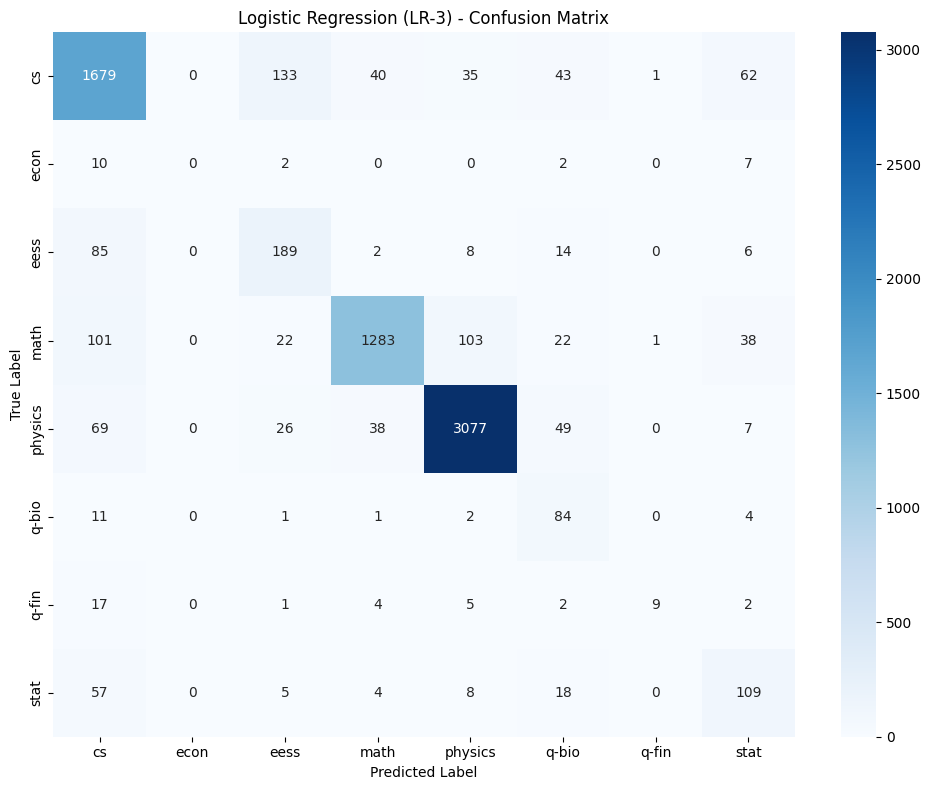

In [ ]:
lr_models = {

    "LR-1": lr_1,

    "LR-2": lr_2,

    "LR-3": lr_3
}
(
    best_lr_model,
    best_lr_config,
    best_lr_val_f1,
    lr_tuning_df
) = select_best_classical_model(
    "Logistic Regression",
    lr_models
)
lr_final_result = evaluate_final_model(
    model=best_lr_model,
    X_test_data=X_test_tfidf,
    y_test_data=y_test,
    model_name=f"Logistic Regression ({best_lr_config})",
    representation="TF-IDF",
    configuration=best_lr_config
)

Naive Bayes HYPERPARAMETER TUNING RESULTS


,model,representation,configuration,hyperparameters,validation_accuracy,validation_macro_f1
0,Naive Bayes,TF-IDF,NB-1,{'alpha': 0.1},0.861030,0.547336
1,Naive Bayes,TF-IDF,NB-2,{'alpha': 0.5},0.841424,0.349677
2,Naive Bayes,TF-IDF,NB-3,{'alpha': 1.0},0.838090,0.326001



Best Configuration:
NB-1

Best Validation Accuracy:
0.861

Best Validation Macro F1:
0.5473
FINAL TEST EVALUATION: Naive Bayes (NB-1)
Best Configuration: NB-1
Representation: TF-IDF
Test Accuracy: 0.8605
Test Macro F1: 0.5331
Test Weighted F1: 0.8541

Classification Report:

              precision    recall  f1-score   support

          cs     0.7760    0.9037    0.8350      1993
        econ     0.0000    0.0000    0.0000        21
        eess     0.5743    0.3816    0.4585       304
        math     0.8392    0.8975    0.8673      1570
     physics     0.9695    0.9155    0.9417      3266
       q-bio     0.7451    0.3689    0.4935       103
       q-fin     1.0000    0.0750    0.1395        40
        stat     0.6013    0.4726    0.5292       201

    accuracy                         0.8605      7498
   macro avg     0.6882    0.5018    0.5331      7498
weighted avg     0.8592    0.8605    0.8541      7498



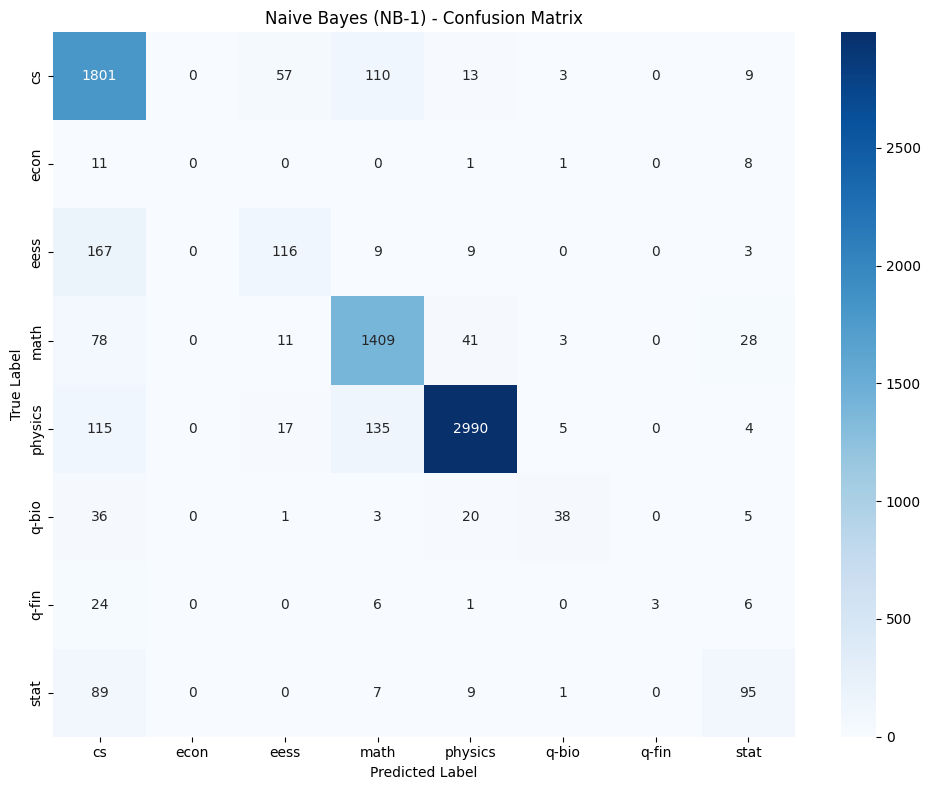

In [ ]:
nb_models = {

    "NB-1": nb_1,

    "NB-2": nb_2,

    "NB-3": nb_3
}
(
    best_nb_model,
    best_nb_config,
    best_nb_val_f1,
    nb_tuning_df
) = select_best_classical_model(
    "Naive Bayes",
    nb_models
)
nb_final_result = evaluate_final_model(
    model=best_nb_model,
    X_test_data=X_test_tfidf,
    y_test_data=y_test,
    model_name=f"Naive Bayes ({best_nb_config})",
    representation="TF-IDF",
    configuration=best_nb_config
)

Random Forest HYPERPARAMETER TUNING RESULTS


,model,representation,configuration,hyperparameters,validation_accuracy,validation_macro_f1
0,Random Forest,TF-IDF,RF-2,"{'n_estimators': 150, 'max_depth': 30, 'min_sa...",0.793278,0.546527
1,Random Forest,TF-IDF,RF-1,"{'n_estimators': 100, 'max_depth': 20, 'min_sa...",0.760469,0.543148
2,Random Forest,TF-IDF,RF-3,"{'n_estimators': 200, 'max_depth': 40, 'min_sa...",0.805548,0.508368



Best Configuration:
RF-2

Best Validation Accuracy:
0.7933

Best Validation Macro F1:
0.5465
FINAL TEST EVALUATION: Random Forest (RF-2)
Best Configuration: RF-2
Representation: TF-IDF
Test Accuracy: 0.7923
Test Macro F1: 0.5459
Test Weighted F1: 0.7918

Classification Report:

              precision    recall  f1-score   support

          cs     0.7707    0.7321    0.7509      1993
        econ     0.0000    0.0000    0.0000        21
        eess     0.3452    0.3520    0.3485       304
        math     0.7230    0.8561    0.7839      1570
     physics     0.9232    0.8803    0.9013      3266
       q-bio     0.5909    0.3786    0.4615       103
       q-fin     0.6522    0.7500    0.6977        40
        stat     0.4143    0.4328    0.4234       201

    accuracy                         0.7923      7498
   macro avg     0.5524    0.5477    0.5459      7498
weighted avg     0.7951    0.7923    0.7918      7498



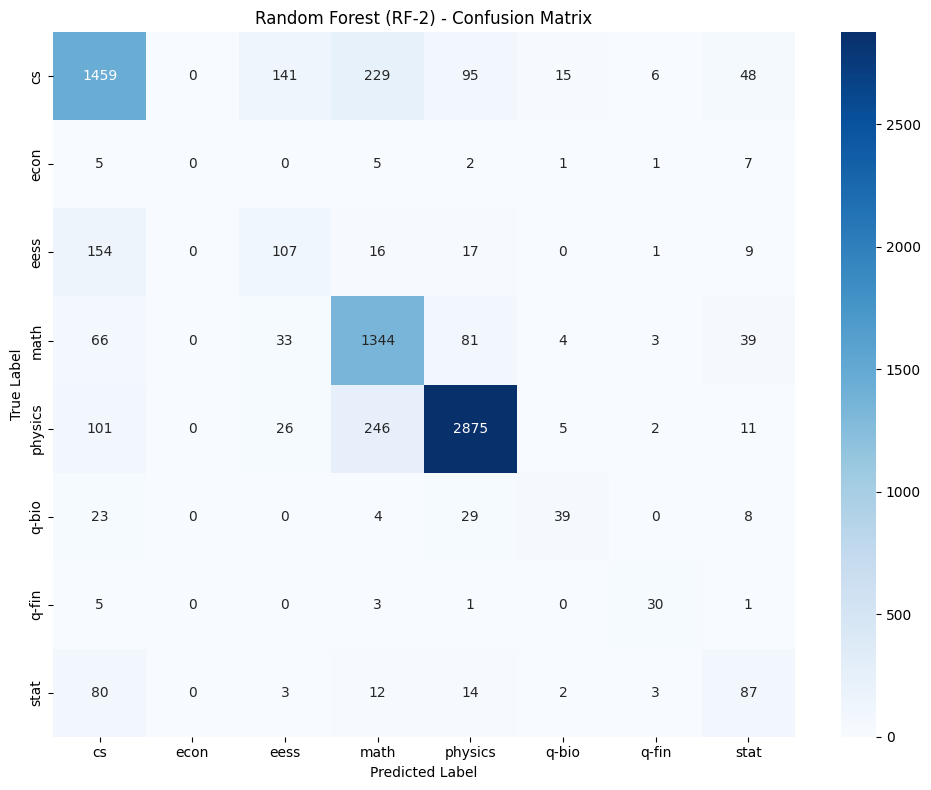

In [ ]:
rf_models = {

    "RF-1": rf_1,

    "RF-2": rf_2,

    "RF-3": rf_3
}
(
    best_rf_model,
    best_rf_config,
    best_rf_val_f1,
    rf_tuning_df
) = select_best_classical_model(
    "Random Forest",
    rf_models
)
rf_final_result = evaluate_final_model(
    model=best_rf_model,
    X_test_data=X_test_tfidf,
    y_test_data=y_test,
    model_name=f"Random Forest ({best_rf_config})",
    representation="TF-IDF",
    configuration=best_rf_config
)

In [ ]:
all_classical_tuning_results = pd.concat(
    [
        lr_tuning_df,
        nb_tuning_df,
        rf_tuning_df
    ],
    ignore_index=True
)

all_classical_tuning_results = (
    all_classical_tuning_results
    .sort_values(
        "validation_macro_f1",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)
display(
    all_classical_tuning_results
)
all_classical_tuning_results.to_csv(
    "classical_hyperparameter_tuning.csv",
    index=False
)

,model,representation,configuration,hyperparameters,validation_accuracy,validation_macro_f1
0,Logistic Regression,TF-IDF,LR-3,"{'C': 4.0, 'solver': 'saga', 'max_iter': 1000,...",0.856095,0.574648
1,Logistic Regression,TF-IDF,LR-2,"{'C': 2.0, 'solver': 'saga', 'max_iter': 1000,...",0.831422,0.571340
2,Naive Bayes,TF-IDF,NB-1,{'alpha': 0.1},0.861030,0.547336
3,Random Forest,TF-IDF,RF-2,"{'n_estimators': 150, 'max_depth': 30, 'min_sa...",0.793278,0.546527
4,Random Forest,TF-IDF,RF-1,"{'n_estimators': 100, 'max_depth': 20, 'min_sa...",0.760469,0.543148
5,Random Forest,TF-IDF,RF-3,"{'n_estimators': 200, 'max_depth': 40, 'min_sa...",0.805548,0.508368
6,Logistic Regression,TF-IDF,LR-1,"{'C': 1.0, 'solver': 'saga', 'max_iter': 1000,...",0.776874,0.486000
7,Naive Bayes,TF-IDF,NB-2,{'alpha': 0.5},0.841424,0.349677
8,Naive Bayes,TF-IDF,NB-3,{'alpha': 1.0},0.838090,0.326001


In [ ]:
best_classical_models_df = (
    all_classical_tuning_results
    .sort_values(
        "validation_macro_f1",
        ascending=False
    )
    .groupby(
        "model",
        as_index=False
    )
    .first()
    .sort_values(
        "validation_macro_f1",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)

print("=" * 70)
print("BEST CLASSICAL MODEL CONFIGURATIONS")
print("=" * 70)

display(
    best_classical_models_df
)

BEST CLASSICAL MODEL CONFIGURATIONS


,model,representation,configuration,hyperparameters,validation_accuracy,validation_macro_f1
0,Logistic Regression,TF-IDF,LR-3,"{'C': 4.0, 'solver': 'saga', 'max_iter': 1000,...",0.856095,0.574648
1,Naive Bayes,TF-IDF,NB-1,{'alpha': 0.1},0.861030,0.547336
2,Random Forest,TF-IDF,RF-2,"{'n_estimators': 150, 'max_depth': 30, 'min_sa...",0.793278,0.546527


Visualization

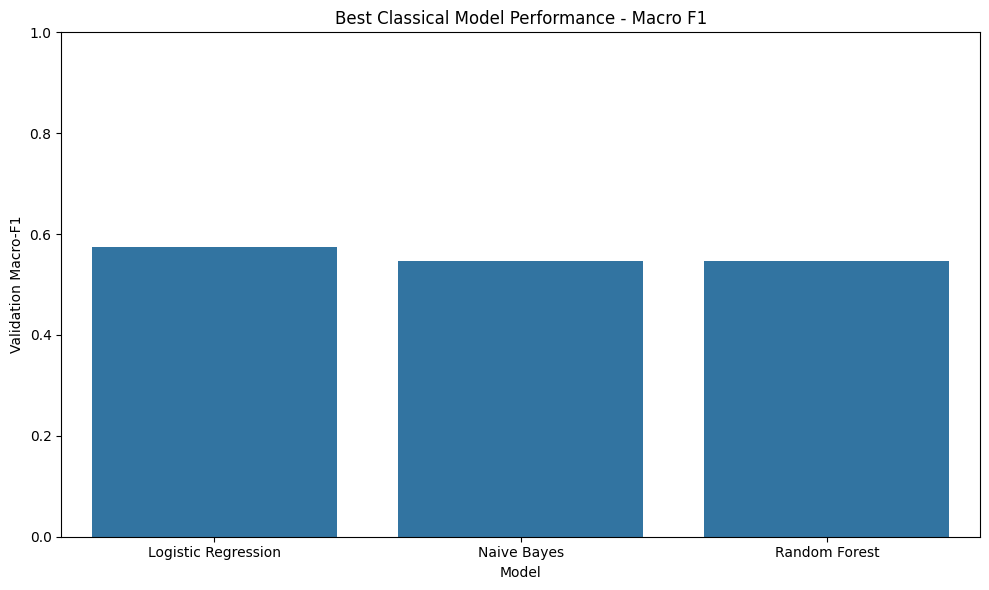

In [ ]:
best_classical_plot = best_classical.copy()

plt.figure(figsize=(10, 6))

sns.barplot(
    data=best_classical_plot,
    x="model",
    y="validation_macro_f1"
)

plt.title(
    "Best Classical Model Performance - Macro F1"
)

plt.xlabel("Model")
plt.ylabel("Validation Macro-F1")

plt.ylim(0, 1)

plt.tight_layout()
plt.show()

Saving Results

In [ ]:
tuning_df.to_csv(
    "classical_tuning_results.csv",
    index=False
)

print(
    "Saved: classical_tuning_results.csv"
)

best_classical.to_csv(
    "best_classical_models.csv",
    index=False
)

print(
    "Saved: best_classical_models.csv"
)

Saved: classical_tuning_results.csv
Saved: best_classical_models.csv


# Word2Vec Representation

Tokenization

In [ ]:
train_tokens = [
    text.split()
    for text in X_train_clean
]

val_tokens = [
    text.split()
    for text in X_val_clean
]

test_tokens = [
    text.split()
    for text in X_test_clean
]

print("Training documents:", len(train_tokens))
print("Validation documents:", len(val_tokens))
print("Test documents:", len(test_tokens))

print("\nExample tokens:")
print(train_tokens[0][:30])

Training documents: 34990
Validation documents: 7498
Test documents: 7498

Example tokens:
['characterising', 'the', 'correlations', 'of', 'prepare-and-measure', 'quantum', 'networks', 'prepare-and-measure', '(p&m)', 'quantum', 'networks', 'are', 'the', 'basic', 'building', 'blocks', 'of', 'quantum', 'communication', 'and', 'cryptography.', 'these', 'networks', 'crucially', 'rely', 'on', 'non-orthogonal', 'quantum', 'encodings', 'to']


Vocabulary Size

In [ ]:
from collections import Counter

word_counter = Counter(
    word
    for document in train_tokens
    for word in document
)

print("Unique training vocabulary:", len(word_counter))

print("\nMost common 30 words:")
print(
    word_counter.most_common(30)
)

Unique training vocabulary: 219117

Most common 30 words:
[('the', 368513), ('of', 231332), ('and', 147060), ('a', 138235), ('in', 120203), ('to', 114690), ('we', 80806), ('for', 71727), ('is', 68644), ('with', 52583), ('that', 52434), ('on', 45306), ('this', 39337), ('by', 35686), ('are', 35558), ('as', 31184), ('an', 29127), ('from', 24629), ('be', 22675), ('which', 21562), ('can', 19146), ('at', 18724), ('our', 17618), ('model', 14393), ('using', 13774), ('it', 12603), ('these', 12322), ('show', 12161), ('data', 11722), ('results', 11512)]


Train Word2Vec

In [ ]:
from gensim.models import Word2Vec
import multiprocessing

w2v_workers = max(
    1,
    multiprocessing.cpu_count() - 1
)

print("Training Word2Vec...")
print("Workers:", w2v_workers)

word2vec_model = Word2Vec(
    sentences=train_tokens,
    vector_size=100,
    window=5,
    min_count=3,
    workers=w2v_workers,
    sg=1,
    negative=5,
    epochs=10,
    seed=SEED
)

print("\nWord2Vec training completed.")

print(
    "Vocabulary size:",
    len(word2vec_model.wv)
)

print(
    "Embedding dimension:",
    word2vec_model.wv.vector_size
)

Training Word2Vec...
Workers: 1

Word2Vec training completed.
Vocabulary size: 61096
Embedding dimension: 100
